<a href="https://colab.research.google.com/github/AleksandraNovo/GP5/blob/main/notebooks/01_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### EDA

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [56]:
!git clone https://github.com/AleksandraNovo/GP5.git

Cloning into 'GP5'...
remote: Enumerating objects: 41, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 41 (delta 14), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (41/41), 2.23 MiB | 3.49 MiB/s, done.
Resolving deltas: 100% (14/14), done.


In [57]:
%cd GP5

/content/GP5/GP5


In [58]:
df = pd.read_csv('data/clothing_table.csv')

In [59]:
df.head()

,filename,image_type,brand_missing,sizetext,cut,stains,price,smell,price_confidence,damage3,...,trend,category,damage2,usage,brand,damage2image,type,damage,damage3image,styleholes
0,front_2023_09_13_05_18_15.png,front,False,NaN,1,1,27,2,High,NaN,...,0,0,NaN,2,0,front,14,NaN,front,False
1,front_2023_11_06_07_07_20.png,front,False,NaN,1,2,32,2,High,NaN,...,2,3,fläckar,0,7,front,20,NaN,front,True
2,front_2023_06_29_13_15_53.png,front,False,NaN,1,1,21,2,High,NaN,...,1,3,NaN,2,20,front,14,NaN,front,False
3,back_2023_12_27_12_24_34.png,back,False,NaN,1,1,35,2,High,nopprigt,...,0,1,nopprigt,2,7,back,7,nopprigt,front,False
4,front_2023_12_21_12_28_39.png,front,True,NaN,1,1,67,2,High,NaN,...,0,1,NaN,1,0,front,20,NaN,front,False


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30192 entries, 0 to 30191
Data columns (total 38 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   filename          30192 non-null  object 
 1   image_type        30192 non-null  object 
 2   brand_missing     30192 non-null  bool   
 3   sizetext          1653 non-null   object 
 4   cut               30192 non-null  int64  
 5   stains            30192 non-null  int64  
 6   price             30192 non-null  int64  
 7   smell             30192 non-null  int64  
 8   price_confidence  23124 non-null  object 
 9   damage3           2010 non-null   object 
 10  season            30192 non-null  int64  
 11  condition         30192 non-null  int64  
 12  usage_confidence  23124 non-null  object 
 13  damage3loc        4957 non-null   object 
 14  annotator         30192 non-null  float64
 15  pattern           30192 non-null  int64  
 16  comment           4648 non-null   object

#### Condition

Изучим есть ли пропуски

In [61]:
df['condition'].isna().sum()

np.int64(0)

In [62]:
df['condition'].value_counts()

,count
condition,
3,10113
5,8047
2,6150
4,4649
1,1233


In [63]:
df['condition'].describe()

,condition
count,30192.000000
mean,3.401663
std,1.194092
min,1.000000
25%,3.000000
50%,3.000000
75%,5.000000
max,5.000000


Видим, что в данном признаке нет пропусков, шкала распределена от 1 до 5, самым популярным значением стало 3

#### Рассмотрим мало заполненные признаки

Для работы с предсказанием цены важно определить какие признаки оставить

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30192 entries, 0 to 30191
Data columns (total 38 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   filename          30192 non-null  object 
 1   image_type        30192 non-null  object 
 2   brand_missing     30192 non-null  bool   
 3   sizetext          1653 non-null   object 
 4   cut               30192 non-null  int64  
 5   stains            30192 non-null  int64  
 6   price             30192 non-null  int64  
 7   smell             30192 non-null  int64  
 8   price_confidence  23124 non-null  object 
 9   damage3           2010 non-null   object 
 10  season            30192 non-null  int64  
 11  condition         30192 non-null  int64  
 12  usage_confidence  23124 non-null  object 
 13  damage3loc        4957 non-null   object 
 14  annotator         30192 non-null  float64
 15  pattern           30192 non-null  int64  
 16  comment           4648 non-null   object

Заметим, что есть пул признаков с "damage", описывающие дефекты айтемов, каждый из которых относится к обжекту, при этом с большим количеством пропусков, превратим каждый в булево значение

In [65]:
damage_cols = ['damage', 'damage2', 'damage3','damageloc', 'damage2loc', 'damage3loc','damageimage', 'damage2image', 'damage3image']
df[damage_cols] = df[damage_cols].map(lambda x: 0 if pd.isna(x) or str(x).strip() == "" else 1)

#### Оставшиеся обжекты

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30192 entries, 0 to 30191
Data columns (total 38 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   filename          30192 non-null  object 
 1   image_type        30192 non-null  object 
 2   brand_missing     30192 non-null  bool   
 3   sizetext          1653 non-null   object 
 4   cut               30192 non-null  int64  
 5   stains            30192 non-null  int64  
 6   price             30192 non-null  int64  
 7   smell             30192 non-null  int64  
 8   price_confidence  23124 non-null  object 
 9   damage3           30192 non-null  int64  
 10  season            30192 non-null  int64  
 11  condition         30192 non-null  int64  
 12  usage_confidence  23124 non-null  object 
 13  damage3loc        30192 non-null  int64  
 14  annotator         30192 non-null  float64
 15  pattern           30192 non-null  int64  
 16  comment           4648 non-null   object

In [67]:
(df['weight'] == 0).sum()

np.int64(30192)

In [68]:
df = df.drop(columns=['material','size','brandtext','cut', 'annotator', 'pattern', 'weight'])

In [69]:
text_cols = ['comment', 'description', 'sizetext']

df[text_cols] = (df[text_cols].notna() & (df[text_cols].astype(str).apply(lambda x: x.str.strip()) != '')).astype(int)

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30192 entries, 0 to 30191
Data columns (total 31 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   filename          30192 non-null  object
 1   image_type        30192 non-null  object
 2   brand_missing     30192 non-null  bool  
 3   sizetext          30192 non-null  int64 
 4   stains            30192 non-null  int64 
 5   price             30192 non-null  int64 
 6   smell             30192 non-null  int64 
 7   price_confidence  23124 non-null  object
 8   damage3           30192 non-null  int64 
 9   season            30192 non-null  int64 
 10  condition         30192 non-null  int64 
 11  usage_confidence  23124 non-null  object
 12  damage3loc        30192 non-null  int64 
 13  comment           30192 non-null  int64 
 14  pilling           30192 non-null  int64 
 15  damageimage       30192 non-null  int64 
 16  damage2loc        30192 non-null  int64 
 17  holes       

In [71]:
df['colors'].value_counts()

,count
colors,
['Black'],4084
['Blue'],3688
['White'],2340
['Grey'],1673
['Pink'],1319
...,...
"['Black', 'Green', 'Red', 'White', 'Beige']",1
"['Multicolor', 'White', 'Orange', 'Black', 'Red', 'Green', 'Grey', 'Brown', 'Yellow', 'Beige']",1
"['Green', 'Pink', 'Multicolor', 'Blue']",1


Оставим от этого признака количество цветов из описания

In [72]:
df['colors'] = df['colors'].fillna('').astype(str).str.strip().apply(lambda x: len([c for c in x.split(",") if c.strip()]) if x else 0)

Переделаем часть признаков в бинарные

In [73]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30192 entries, 0 to 30191
Data columns (total 31 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   filename          30192 non-null  object
 1   image_type        30192 non-null  object
 2   brand_missing     30192 non-null  int64 
 3   sizetext          30192 non-null  int64 
 4   stains            30192 non-null  int64 
 5   price             30192 non-null  int64 
 6   smell             30192 non-null  int64 
 7   price_confidence  23124 non-null  object
 8   damage3           30192 non-null  int64 
 9   season            30192 non-null  int64 
 10  condition         30192 non-null  int64 
 11  usage_confidence  23124 non-null  object
 12  damage3loc        30192 non-null  int64 
 13  comment           30192 non-null  int64 
 14  pilling           30192 non-null  int64 
 15  damageimage       30192 non-null  int64 
 16  damage2loc        30192 non-null  int64 
 17  holes       

In [75]:
df['price_confidence'] = df['price_confidence'].map({'High': 3, 'Medium': 2, 'Low': 1})
df['usage_confidence'] = df['usage_confidence'].map({'High': 3, 'Medium': 2, 'Low': 1})

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30192 entries, 0 to 30191
Data columns (total 31 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   filename          30192 non-null  object 
 1   image_type        30192 non-null  object 
 2   brand_missing     30192 non-null  int64  
 3   sizetext          30192 non-null  int64  
 4   stains            30192 non-null  int64  
 5   price             30192 non-null  int64  
 6   smell             30192 non-null  int64  
 7   price_confidence  23124 non-null  float64
 8   damage3           30192 non-null  int64  
 9   season            30192 non-null  int64  
 10  condition         30192 non-null  int64  
 11  usage_confidence  23124 non-null  float64
 12  damage3loc        30192 non-null  int64  
 13  comment           30192 non-null  int64  
 14  pilling           30192 non-null  int64  
 15  damageimage       30192 non-null  int64  
 16  damage2loc        30192 non-null  int64 

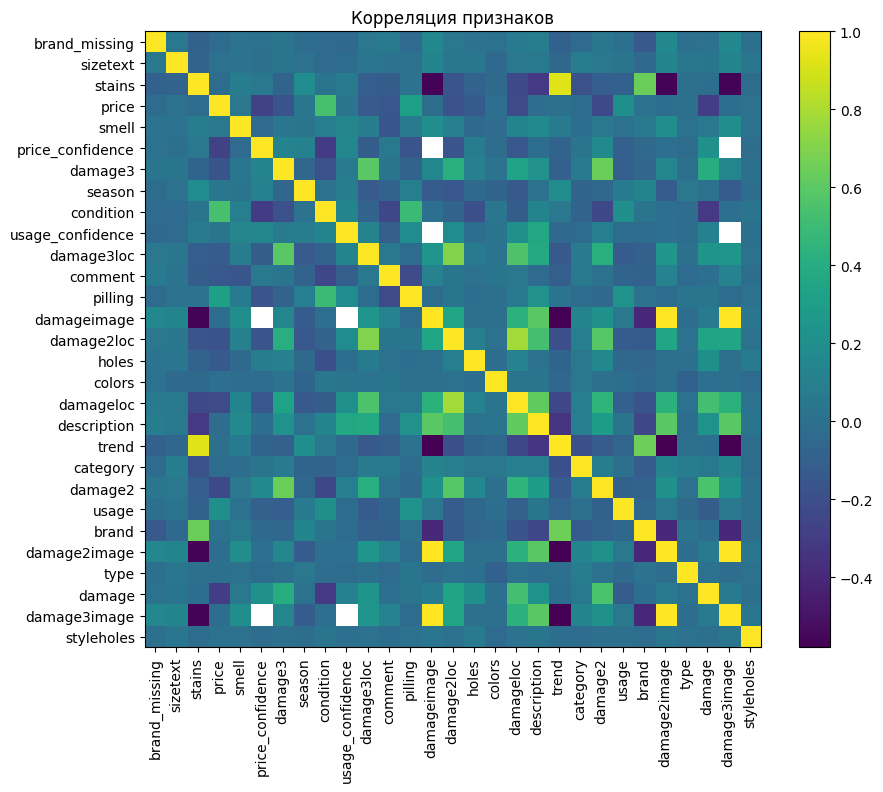

In [77]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix)
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Корреляция признаков")
plt.show()

Удалим все признаки коррелирующие с другими признаками (не с таргетом)

In [78]:
df = df.drop(columns=[
    'damageimage',
    'damage2image',
    'trend',
    'damage3image',
    'damage2loc',
    'description',
    'damage3loc',
    'brand',
    'damage2',
    'damage3',
    'damageloc',
    'pilling'])

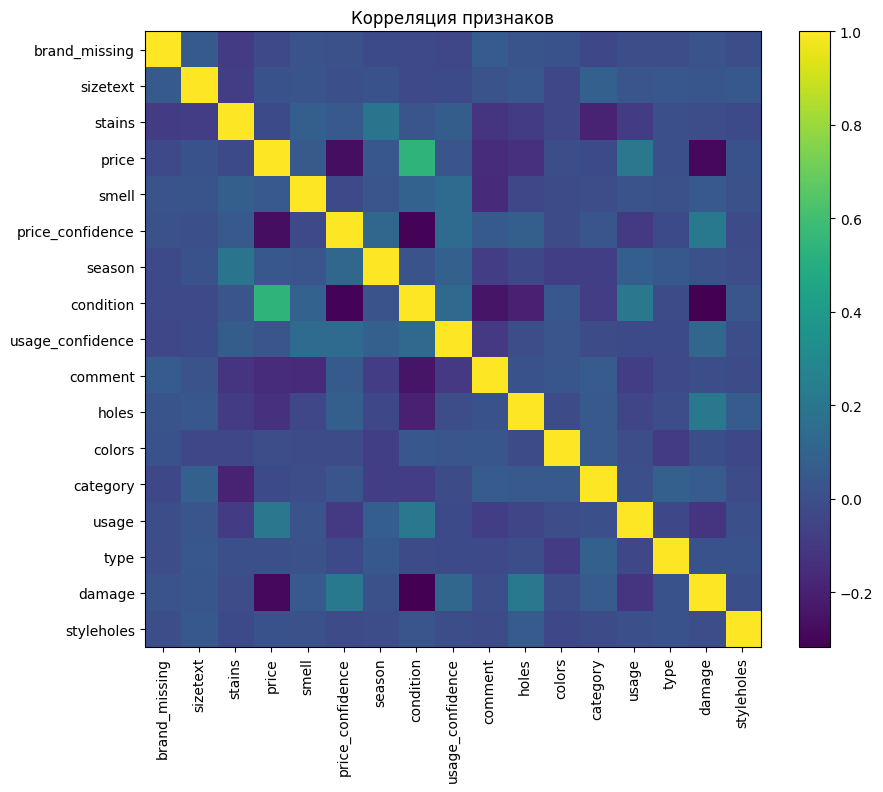

In [79]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix)
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Корреляция признаков")
plt.show()

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30192 entries, 0 to 30191
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   filename          30192 non-null  object 
 1   image_type        30192 non-null  object 
 2   brand_missing     30192 non-null  int64  
 3   sizetext          30192 non-null  int64  
 4   stains            30192 non-null  int64  
 5   price             30192 non-null  int64  
 6   smell             30192 non-null  int64  
 7   price_confidence  23124 non-null  float64
 8   season            30192 non-null  int64  
 9   condition         30192 non-null  int64  
 10  usage_confidence  23124 non-null  float64
 11  comment           30192 non-null  int64  
 12  holes             30192 non-null  int64  
 13  colors            30192 non-null  int64  
 14  category          30192 non-null  int64  
 15  usage             30192 non-null  int64  
 16  type              30192 non-null  int64 

In [81]:
df = df.dropna(subset=['usage_confidence', 'price_confidence'])

In [82]:
df['brand'] = 1 - df['brand_missing'].astype(int)
df = df.drop(columns=['brand_missing'])

In [83]:
df.head()

,filename,image_type,sizetext,stains,price,smell,price_confidence,season,condition,usage_confidence,comment,holes,colors,category,usage,type,damage,styleholes,brand
0,front_2023_09_13_05_18_15.png,front,0,1,27,2,3.0,2,2,3.0,0,0,3,0,2,14,0,0,1
1,front_2023_11_06_07_07_20.png,front,0,2,32,2,3.0,2,3,3.0,0,0,1,3,0,20,0,1,1
2,front_2023_06_29_13_15_53.png,front,0,1,21,2,3.0,2,3,1.0,0,0,2,3,2,14,0,0,1
3,back_2023_12_27_12_24_34.png,back,0,1,35,2,3.0,2,2,3.0,1,0,3,1,2,7,1,0,1
4,front_2023_12_21_12_28_39.png,front,0,1,67,2,3.0,2,5,3.0,1,0,1,1,1,20,0,0,0


#### Проверим кодировки категориальных признаков

In [84]:
df['image_type'] = df['image_type'].map({'front': 0,'back': 1}).astype(int)

In [85]:
df['season'].value_counts()

,count
season,
2,18431
5,2641
3,1306
0,264
4,249
1,233


In [86]:
season_map = {
    0: 'spring',
    1: 'autumn',
    2: 'all_seasons',
    3: 'summer',
    4: 'winter',
    5: 'unknown'}

df['season'] = df['season'].map(season_map)

df = pd.get_dummies(
    df,
    columns=['season'],
    drop_first=False,
    dtype=int)

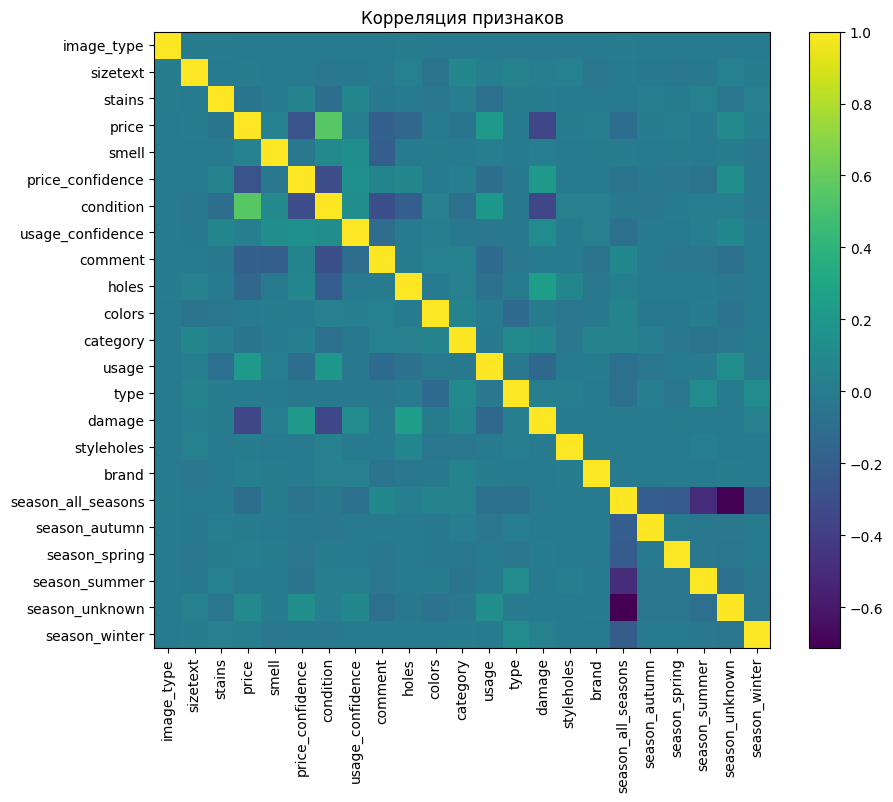

In [87]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix)
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Корреляция признаков")
plt.show()

In [88]:
df = df.drop(columns=['season_summer', 'season_unknown'])

In [89]:
df['category'].value_counts()

,count
category,
0,14320
1,4499
3,3421
2,874
5,8
4,1
7,1


In [90]:
df = df[~df['category'].isin([7, 4, 5])]
df['category'].value_counts()

,count
category,
0,14320
1,4499
3,3421
2,874


In [91]:
category_map = {
    0: 'female',
    1: 'kids',
    2: 'unisex',
    3: 'male'}

df['category'] = df['category'].map(category_map)

df = pd.get_dummies(
    df,
    columns=['category'],
    drop_first=False,
    dtype=int)

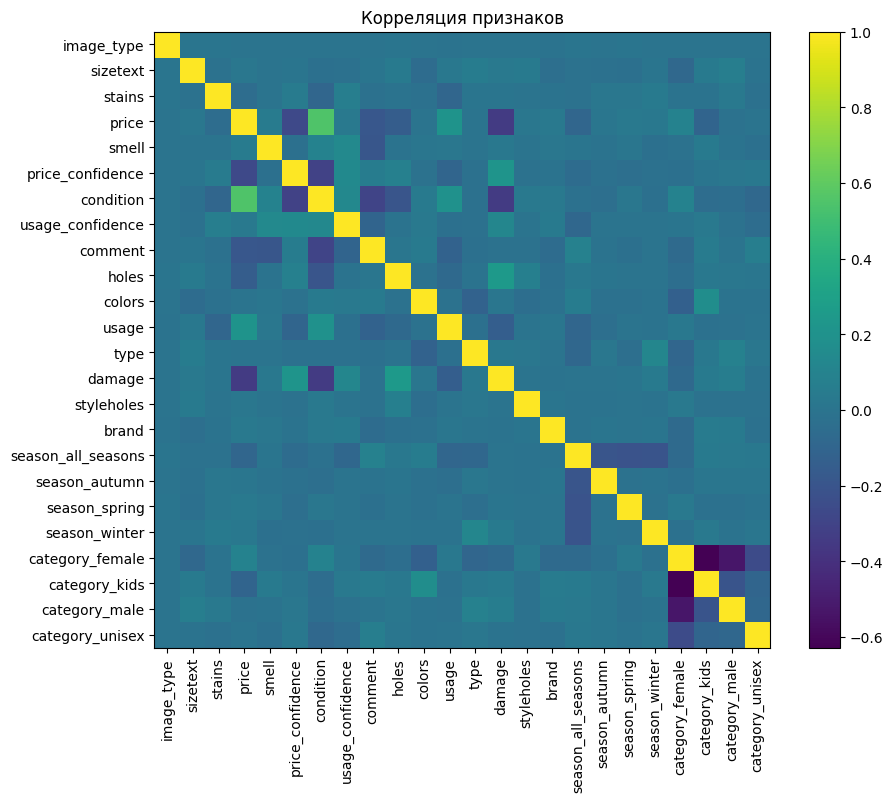

In [92]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix)
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Корреляция признаков")
plt.show()

In [93]:
df = df.drop(columns=['category_kids', 'category_male'])
df.head()

,filename,image_type,sizetext,stains,price,smell,price_confidence,condition,usage_confidence,comment,...,type,damage,styleholes,brand,season_all_seasons,season_autumn,season_spring,season_winter,category_female,category_unisex
0,front_2023_09_13_05_18_15.png,0,0,1,27,2,3.0,2,3.0,0,...,14,0,0,1,1,0,0,0,1,0
1,front_2023_11_06_07_07_20.png,0,0,2,32,2,3.0,3,3.0,0,...,20,0,1,1,1,0,0,0,0,0
2,front_2023_06_29_13_15_53.png,0,0,1,21,2,3.0,3,1.0,0,...,14,0,0,1,1,0,0,0,0,0
3,back_2023_12_27_12_24_34.png,1,0,1,35,2,3.0,2,3.0,1,...,7,1,0,1,1,0,0,0,0,0
4,front_2023_12_21_12_28_39.png,0,0,1,67,2,3.0,5,3.0,1,...,20,0,0,0,1,0,0,0,0,0


In [94]:
df['usage'].value_counts()

,count
usage,
1,11736
0,8842
2,2110
4,186
5,104
3,103
6,12
7,11
8,8


In [95]:
df = df[~df['usage'].isin([6, 7, 8, 9])]

In [96]:
usage_order = {
    3: 0,  #energy_recovery — самое низкое качество/ценность
    2: 1,  #recycle
    4: 2,  #remake
    5: 3,  #repair
    0: 4,  #export
    1: 5   #reuse — можно использовать как есть
        }

df['usage'] = df['usage'].map(usage_order)

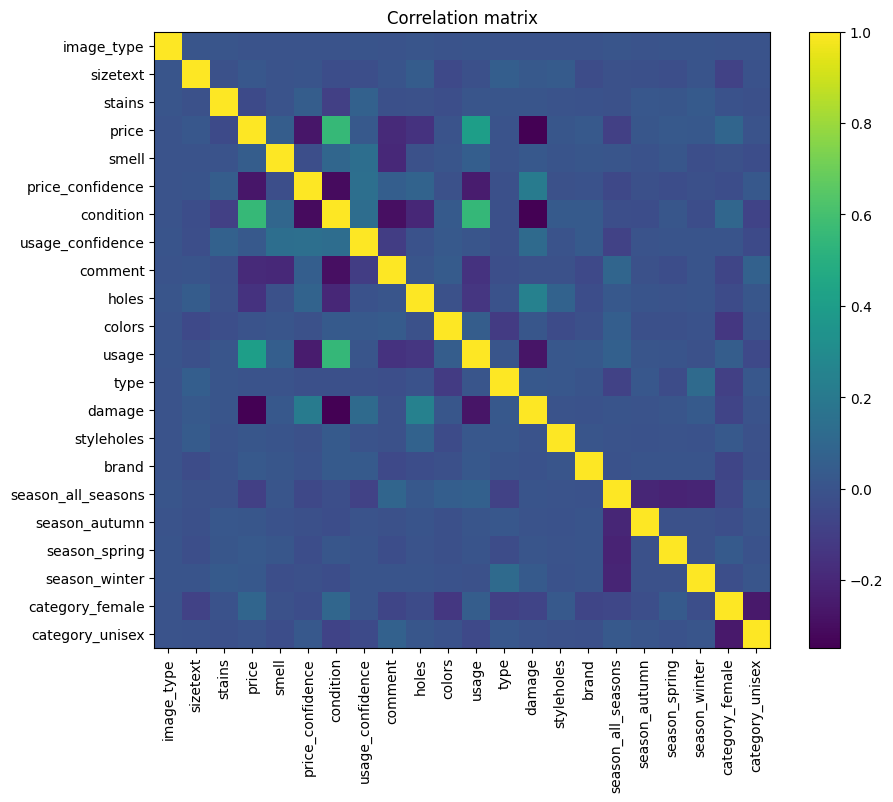

In [97]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix)
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation matrix")
plt.show()

#### Итог

In [98]:
price_corr = df.corr(numeric_only=True)['price']

strong_corr = (
    price_corr
    .drop('price')
    .loc[lambda x: x.abs() > 0.3]
    .sort_values(key=abs, ascending=False))

strong_corr

,price
condition,0.553330
usage,0.408249
damage,-0.347271


In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23081 entries, 0 to 30189
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   filename            23081 non-null  object 
 1   image_type          23081 non-null  int64  
 2   sizetext            23081 non-null  int64  
 3   stains              23081 non-null  int64  
 4   price               23081 non-null  int64  
 5   smell               23081 non-null  int64  
 6   price_confidence    23081 non-null  float64
 7   condition           23081 non-null  int64  
 8   usage_confidence    23081 non-null  float64
 9   comment             23081 non-null  int64  
 10  holes               23081 non-null  int64  
 11  colors              23081 non-null  int64  
 12  usage               23081 non-null  int64  
 13  type                23081 non-null  int64  
 14  damage              23081 non-null  int64  
 15  styleholes          23081 non-null  int64  
 16  brand    

In [100]:
df = df.reset_index(drop=True)

In [101]:
usage_labels = {
    0: 'Energy recovery',
    1: 'Recycle',
    2: 'Remake',
    3: 'Repair',
    4: 'Export',
    5: 'Reuse'
}

eda = df.copy()

eda['usage_label'] = pd.Categorical(
    eda['usage'].map(usage_labels),
    categories=list(usage_labels.values()),
    ordered=True
)

eda['damage_label'] = eda['damage'].map({
    0: 'Без повреждений',
    1: 'Есть повреждения'
})

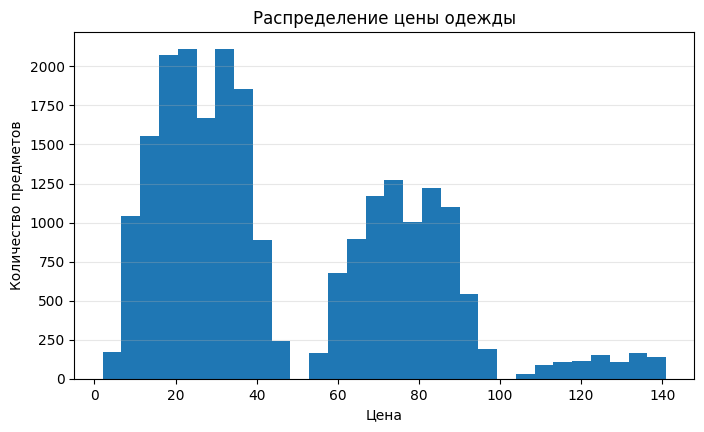

In [102]:
max_price = eda['price'].quantile(0.99)

prices = eda.loc[eda['price'] <= max_price, 'price']

fig, ax = plt.subplots(figsize=(8, 4.5))

prices.plot(
    kind='hist',
    bins=30,
    ax=ax
)

ax.set_title('Распределение цены одежды')
ax.set_xlabel('Цена')
ax.set_ylabel('Количество предметов')
ax.grid(axis='y', alpha=0.3)

plt.show()

Цена распределена неравномерно: большинство вещей находится в нижнем и среднем ценовом диапазоне, при этом есть отдельные дорогие позиции

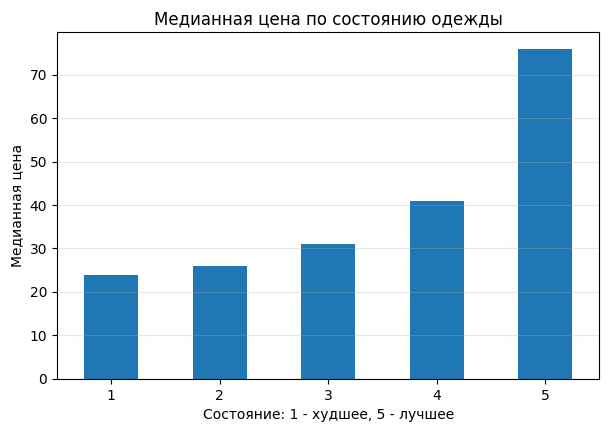

In [103]:
price_cond = eda.groupby('condition')['price'].median()

fig, ax = plt.subplots(figsize=(7, 4.5))

price_cond.plot(kind='bar', ax=ax)

ax.set_title('Медианная цена по состоянию одежды')
ax.set_xlabel('Состояние: 1 - худшее, 5 - лучшее')
ax.set_ylabel('Медианная цена')
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', alpha=0.3)

plt.show()

Чем выше состояние одежды, тем выше медианная цена, что подтверждает важность признака condition для оценки стоимости вещей

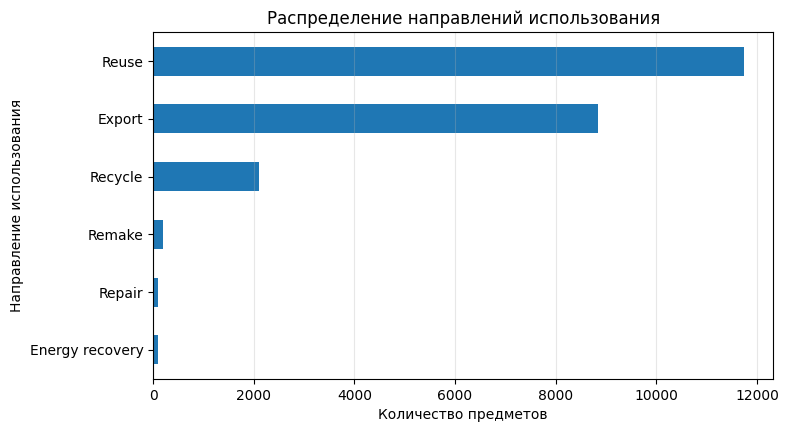

In [104]:
usage_count = eda['usage_label'].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(8, 4.5))

usage_count.plot(kind='barh', ax=ax)

ax.set_title('Распределение направлений использования')
ax.set_xlabel('Количество предметов')
ax.set_ylabel('Направление использования')
ax.grid(axis='x', alpha=0.3)

plt.show()

Наши данные несбалансированы: основная часть вещей относится к Reuse и Export, а Repair, Remake и Energy recovery встречаются значительно реже

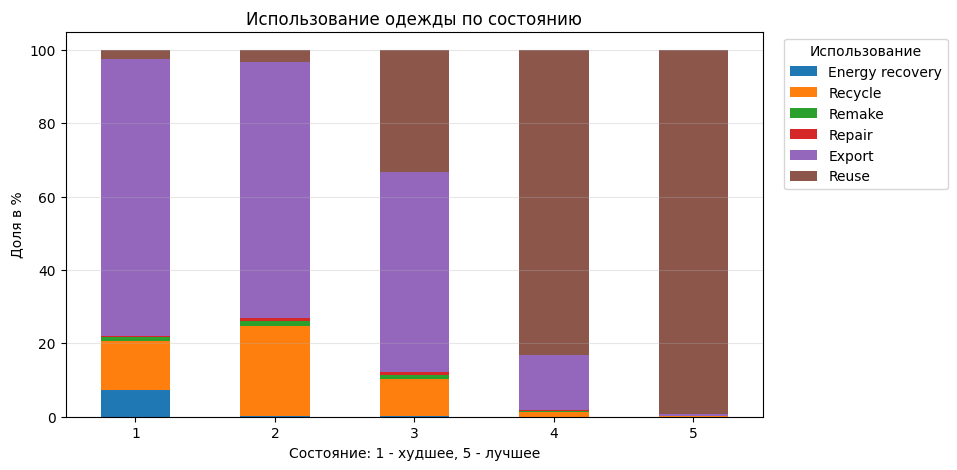

In [105]:
usage_part = (
    pd.crosstab(eda['condition'], eda['usage_label'], normalize='index') * 100
)

ax = usage_part.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 5)
)

ax.set_title('Использование одежды по состоянию')
ax.set_xlabel('Состояние: 1 - худшее, 5 - лучшее')
ax.set_ylabel('Доля в %')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Использование', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)

plt.show()

Condition связан с дальнейшим направлением использования, так как вещи в хорошем состоянии чаще идут в Reuse, а в плохом - растет доля Export, Recycle и Energy recovery

# Распределение цен на одежду: сравнение состояния и наличия повреждений

/tmp/ipykernel_7689/3552010631.py:8: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


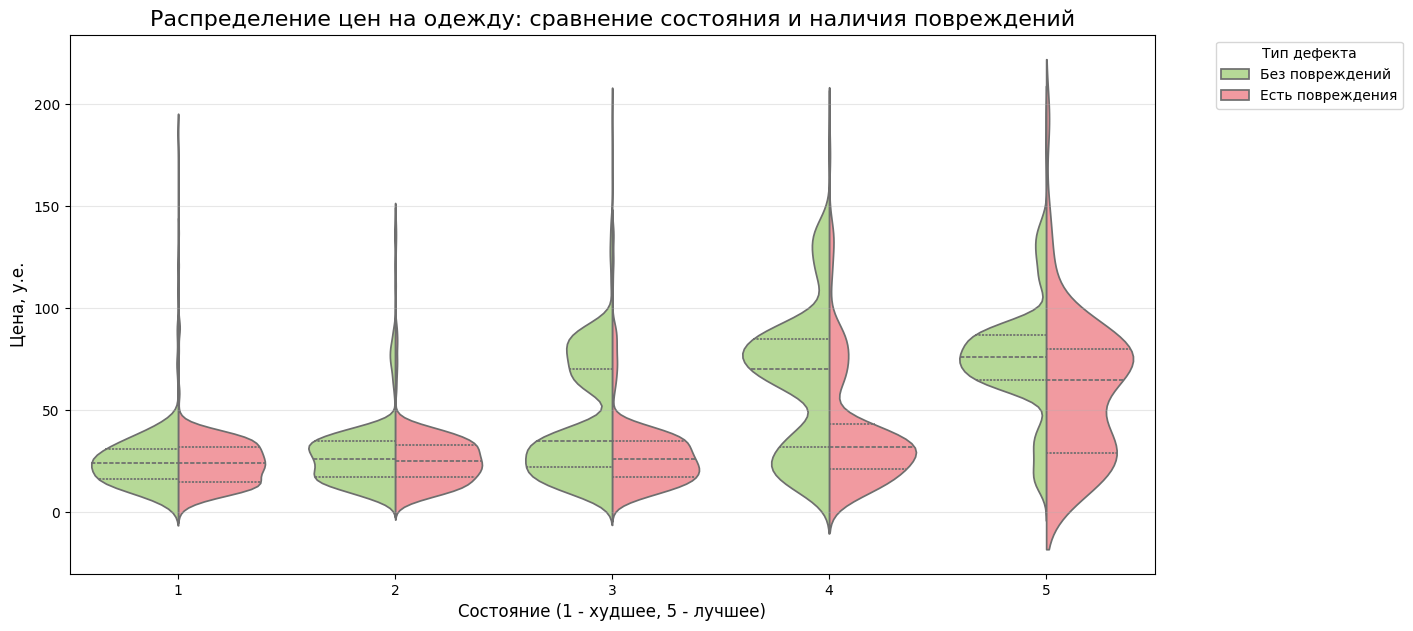

In [115]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_data = eda[eda['price'] <= 200].copy()

plt.figure(figsize=(14, 7))

ax = sns.violinplot(
    x='condition',
    y='price',
    hue='damage_label',
    data=plot_data,
    split=True,
    palette={"Без повреждений": "#b5e48c", "Есть повреждения": "#ff8c94"},
    inner='quartile',
    scale='width'
)


ax.set_title('Распределение цен на одежду: сравнение состояния и наличия повреждений', fontsize=16)
ax.set_xlabel('Состояние (1 - худшее, 5 - лучшее)', fontsize=12)
ax.set_ylabel('Цена, у.е.', fontsize=12)
ax.legend(title='Тип дефекта', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)

plt.show()

С ростом состояния (condition) медианная цена увеличивается

Для condition=4 и 5 наблюдаются длинные нижние хвосты (дешевые вещи в хорошем состоянии)

Наличие повреждений (damage=1) систематически снижает цену во всех состояниях

Разброс цен максимален для condition=3 (самая массовая категория)

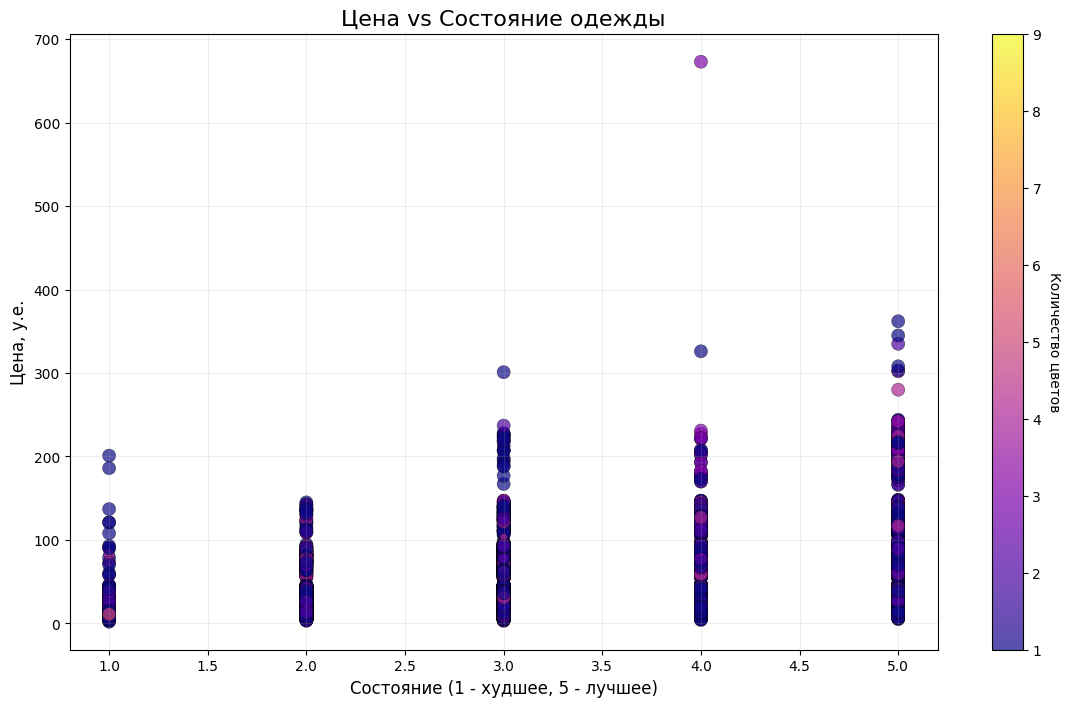

In [123]:
import matplotlib.patches as mpatches

plt.figure(figsize=(14, 8))

scatter = plt.scatter(
    eda['condition'],
    eda['price'],
    c=eda['colors'],
    s=eda['usage_confidence'] * 30,
    alpha=0.7,
    cmap='plasma',
    edgecolors='black',
    linewidth=0.3
)

cbar = plt.colorbar(scatter)
cbar.set_label('Количество цветов', rotation=270, labelpad=15)

plt.title('Цена vs Состояние одежды', fontsize=16)
plt.xlabel('Состояние (1 - худшее, 5 - лучшее)', fontsize=12)
plt.ylabel('Цена, у.е.', fontsize=12)
plt.grid(alpha=0.2)
plt.show()

На графике видна четкая связь между состоянием одежды и ценой: чем выше condition, тем дороже вещи. Наибольший разброс цен наблюдается у среднего состояния (condition=3), а дорогие вещи чаще имеют больше цветов и более высокую уверенность оценщиков. Состояние является ключевым, но не единственным фактором ценообразования

In [106]:
df.to_csv('data/clothing_table_regression.csv', index=False)

По итогам EDA видно, что ключевыми признаками для дальнейшего моделирования являются condition, usage и damage. Состояние одежды связано как с ценой, так и с дальнейшим направлением использования.

Большинство вещей находится в низком и среднем ценовом диапазоне, при этом более качественные вещи имеют более высокую медианную цену.